# Ноутбук 3 — Разведочный анализ данных и целевых переменных

**Назначение.** Анализ распределения SSQ и arousal, корреляция признаков
с arousal, иллюстрация межиндивидуальной вариативности.

**Входы.** `feature_table.csv` (после ноутбука 2).

**Выходы.** Графики `figures/fig01..fig06.png`, описательная статистика.

In [1]:
import sys
from pathlib import Path

NB_ROOT = Path.cwd()
if str(NB_ROOT) not in sys.path:
    sys.path.insert(0, str(NB_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from modules import config

FIG_DIR = config.RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Notebooks root: {NB_ROOT}")
print(f"Figures: {FIG_DIR}")

Notebooks root: D:\Programming\Python\Diplom\notebooks
Figures: D:\Programming\Python\Diplom\source\results\figures


In [2]:
df = pd.read_csv(config.RESULTS_DIR / "feature_table.csv")
print(f"Окон: {len(df):,}")
print(f"Участников: {df['participant'].nunique()}")

Окон: 15,104
Участников: 32


## 3.1 Распределение SSQ Total Score (post-сессия) — fig01

SSQ post:  среднее = 23.14 ± 25.85
SSQ post:  медиана = 13.09, максимум = 97.24
SSQ > 15:  14/32 участников


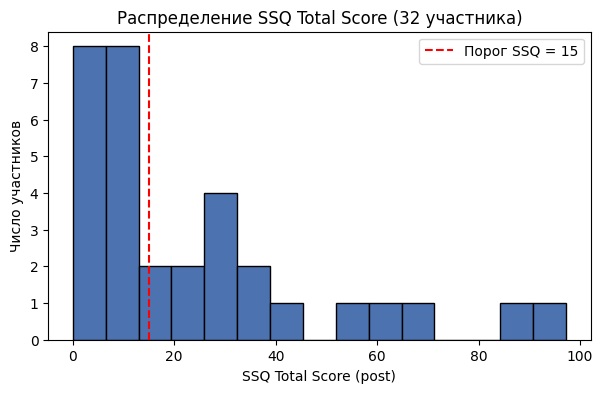

In [3]:
ssq_per_pid = df.groupby("participant")[["ssq_post_total", "ssq_pre_total"]].first()
ssq_per_pid["ssq_delta"] = ssq_per_pid["ssq_post_total"] - ssq_per_pid["ssq_pre_total"]

print(f"SSQ post:  среднее = {ssq_per_pid['ssq_post_total'].mean():.2f} ± "
      f"{ssq_per_pid['ssq_post_total'].std():.2f}")
print(f"SSQ post:  медиана = {ssq_per_pid['ssq_post_total'].median():.2f}, "
      f"максимум = {ssq_per_pid['ssq_post_total'].max():.2f}")
print(f"SSQ > 15:  {(ssq_per_pid['ssq_post_total'] > 15).sum()}/32 участников")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ssq_per_pid["ssq_post_total"], bins=15, color="#4C72B0", edgecolor="black")
ax.axvline(15, color="red", linestyle="--", label="Порог SSQ = 15")
ax.set_xlabel("SSQ Total Score (post)")
ax.set_ylabel("Число участников")
ax.set_title("Распределение SSQ Total Score (32 участника)")
ax.legend()
fig.savefig(FIG_DIR / "fig01_ssq_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.2 SSQ pre vs post — fig02

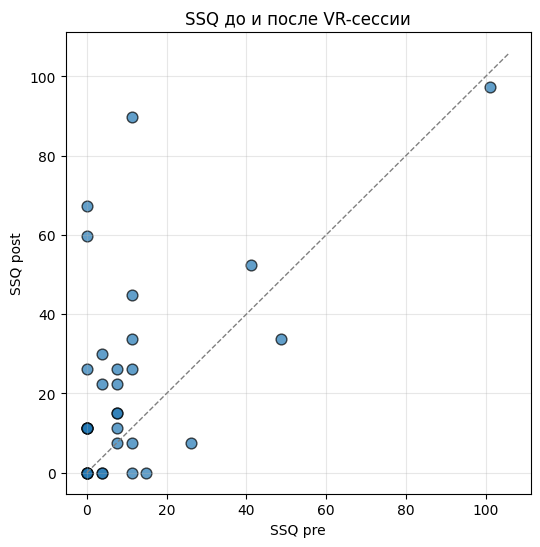

Δ SSQ: среднее = 11.92, медиана = 9.35
Δ > 0 у 19/32 участников
Δ > 15 у 9/32 участников


In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(ssq_per_pid["ssq_pre_total"], ssq_per_pid["ssq_post_total"],
           s=60, alpha=0.7, edgecolor="black")
lim = max(ssq_per_pid["ssq_post_total"].max(), ssq_per_pid["ssq_pre_total"].max()) + 5
ax.plot([0, lim], [0, lim], color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("SSQ pre")
ax.set_ylabel("SSQ post")
ax.set_title("SSQ до и после VR-сессии")
ax.grid(alpha=0.3)
fig.savefig(FIG_DIR / "fig02_ssq_pre_vs_post.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Δ SSQ: среднее = {ssq_per_pid['ssq_delta'].mean():.2f}, "
      f"медиана = {ssq_per_pid['ssq_delta'].median():.2f}")
print(f"Δ > 0 у {(ssq_per_pid['ssq_delta'] > 0).sum()}/32 участников")
print(f"Δ > 15 у {(ssq_per_pid['ssq_delta'] > 15).sum()}/32 участников")

## 3.3 SSQ субшкалы (Nausea / Oculomotor / Disorientation) — fig03

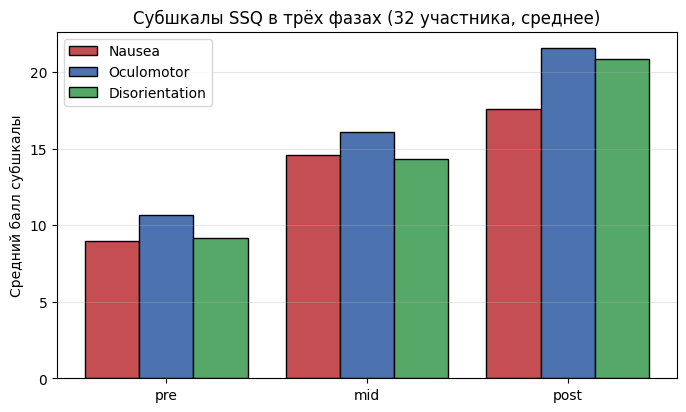

       Nausea  Oculomotor  Disorientation
phase                                    
pre      8.94       10.66            9.14
mid     14.61       16.11           14.36
post    17.59       21.56           20.88


In [5]:
ssq_all = pd.read_csv(config.RESULTS_DIR / "ssq_all.csv")
phase_means = ssq_all.groupby("phase")[["Nausea", "Oculomotor", "Disorientation"]].mean()
phase_means = phase_means.reindex(["pre", "mid", "post"])

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(phase_means))
w = 0.27
ax.bar(x - w, phase_means["Nausea"], w, label="Nausea", color="#C44E52", edgecolor="black")
ax.bar(x,     phase_means["Oculomotor"], w, label="Oculomotor", color="#4C72B0", edgecolor="black")
ax.bar(x + w, phase_means["Disorientation"], w, label="Disorientation", color="#55A868", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(["pre", "mid", "post"])
ax.set_ylabel("Средний балл субшкалы")
ax.set_title("Субшкалы SSQ в трёх фазах (32 участника, среднее)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.savefig(FIG_DIR / "fig03_ssq_subscales.png", dpi=150, bbox_inches="tight")
plt.show()
print(phase_means.round(2).to_string())

## 3.4 Распределение arousal по окнам — fig04

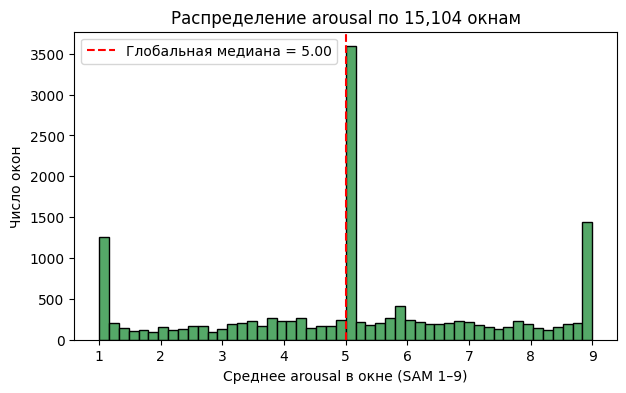

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["arousal_mean"], bins=50, color="#55A868", edgecolor="black")
ax.axvline(df["arousal_mean"].median(), color="red", linestyle="--",
           label=f"Глобальная медиана = {df['arousal_mean'].median():.2f}")
ax.set_xlabel("Среднее arousal в окне (SAM 1–9)")
ax.set_ylabel("Число окон")
ax.set_title(f"Распределение arousal по {len(df):,} окнам")
ax.legend()
fig.savefig(FIG_DIR / "fig04_arousal_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.5 Межиндивидуальная вариативность arousal — fig05

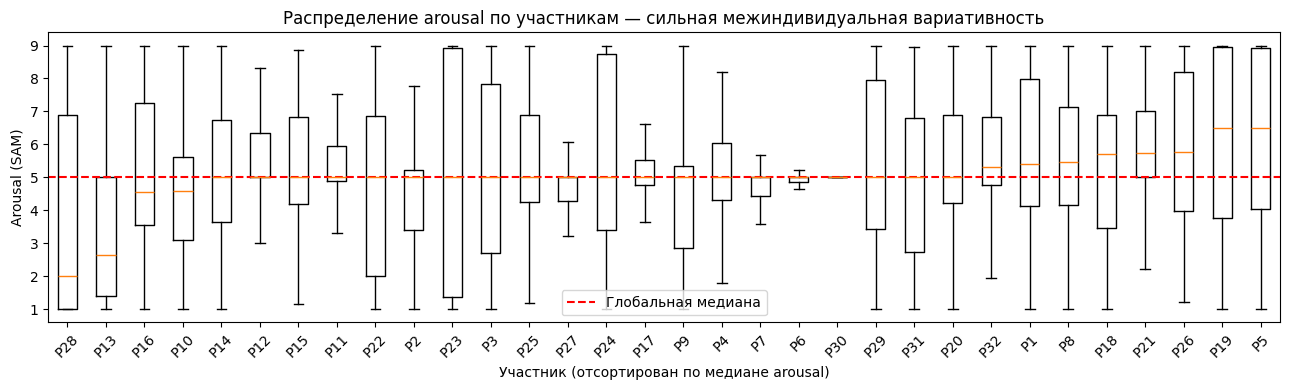

In [7]:
fig, ax = plt.subplots(figsize=(13, 4))
order = df.groupby("participant")["arousal_mean"].median().sort_values().index.tolist()
data_per_pid = [df[df["participant"] == p]["arousal_mean"].values for p in order]
ax.boxplot(data_per_pid, labels=order, showfliers=False)
ax.axhline(5, color="red", linestyle="--", label="Глобальная медиана")
ax.set_xlabel("Участник (отсортирован по медиане arousal)")
ax.set_ylabel("Arousal (SAM)")
ax.set_title("Распределение arousal по участникам — сильная межиндивидуальная вариативность")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig(FIG_DIR / "fig05_arousal_per_participant.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.6 Корреляция признаков с arousal (топ-25) — fig06

Топ-15 признаков по |corr| с arousal:
head_pitch_mean       0.156
head_pitch_median     0.155
head_pitch_max        0.149
head_pitch_min        0.145
gaze_pitch_rms        0.135
right_pupil_median    0.132
left_pupil_median     0.132
left_pupil_mean       0.131
right_pupil_mean      0.131
left_pupil_rms        0.130
right_pupil_rms       0.130
right_pupil_min       0.116
left_pupil_min        0.116
head_yaw_rms         -0.111
gaze_yaw_rms         -0.110


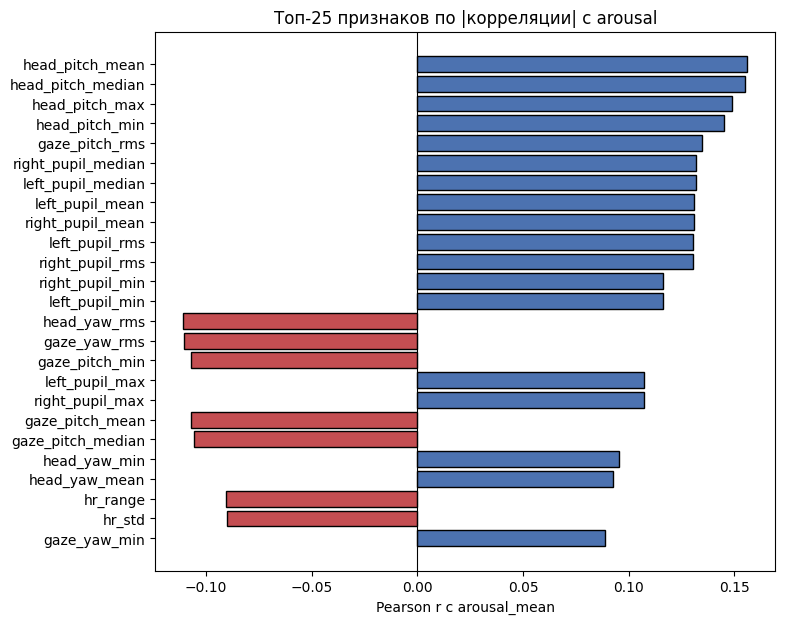

In [8]:
NON_FEAT = {"participant", "video", "window_idx", "t_start", "t_end",
            "arousal_mean", "valence_mean", "ssq_post_total", "ssq_pre_total",
            "ssq_delta", "arousal_class_bin", "arousal_class_tri", "ssq_high"}
feat_cols = [c for c in df.columns if c not in NON_FEAT]

corrs = df[feat_cols].apply(lambda c: c.corr(df["arousal_mean"]))
corrs_sorted = corrs.reindex(corrs.abs().sort_values(ascending=False).index)
print("Топ-15 признаков по |corr| с arousal:")
print(corrs_sorted.head(15).round(3).to_string())

top25 = corrs_sorted.head(25)[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in top25.values]
ax.barh(top25.index, top25.values, color=colors, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson r с arousal_mean")
ax.set_title("Топ-25 признаков по |корреляции| с arousal")
fig.savefig(FIG_DIR / "fig06_feature_corr_with_arousal.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.7 Выводы из EDA

* SSQ post Total имеет асимметричное распределение с тяжёлым правым хвостом
  (среднее 23,14, медиана 13,09, максимум 97,24); 14/32 участников превышают
  клинический порог 15.
* У 8/32 Δ SSQ < 0 — значение опросника после сессии снизилось (нормализация
  исходного состояния), что мотивирует ввод дополнительной метрики SSQ-дельты.
* Распределения arousal сильно различаются между участниками: индивидуальные
  медианы варьируются от ~2 до ~7, что делает глобальный порог = 5,0
  непригодным как универсальную бинаризацию.
* Линейные корреляции отдельных признаков с arousal малы (|r| ≤ 0,16) — отсюда
  необходимость многомерных нелинейных моделей.

Дальнейший шаг — baseline-модели с обоими режимами валидации (ноутбук 4).